In [1]:
import json

import boto3
import pandas as pd
import awswrangler as wr
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
SECRET_ID = "itam/rds/northwind/credentials"
REGION = "us-east-1"
REPLICA_HOST = "itam-northwind-replica-864475311845.c45igc4gw9s5.us-east-1.rds.amazonaws.com"


def get_db_credentials(secret_id: str, region: str) -> dict:
    client = boto3.client("secretsmanager", region_name=region)
    secret = client.get_secret_value(SecretId=secret_id)
    return json.loads(secret["SecretString"])


creds = get_db_credentials(SECRET_ID, REGION)

replica_engine = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}"
    f"@{REPLICA_HOST}:{creds['port']}/{creds['dbname']}"
)

In [3]:
pd.read_sql("SELECT COUNT(*) AS total_flights FROM flights;", replica_engine)

,total_flights
0,500000


# 7. Flights Analytics

## Queries en PostgreSQL (Read Replica)

En esta sección se responden las preguntas P1–P5, W1 y W3 usando SQL sobre la Read Replica de PostgreSQL.

In [4]:
# P1

query_p1 = """
SELECT 
    origin_airport,
    destination_airport,
    COUNT(*) AS total_flights
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_flights DESC
LIMIT 10;
"""

df_p1 = pd.read_sql(query_p1, replica_engine)
df_p1

,origin_airport,destination_airport,total_flights
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


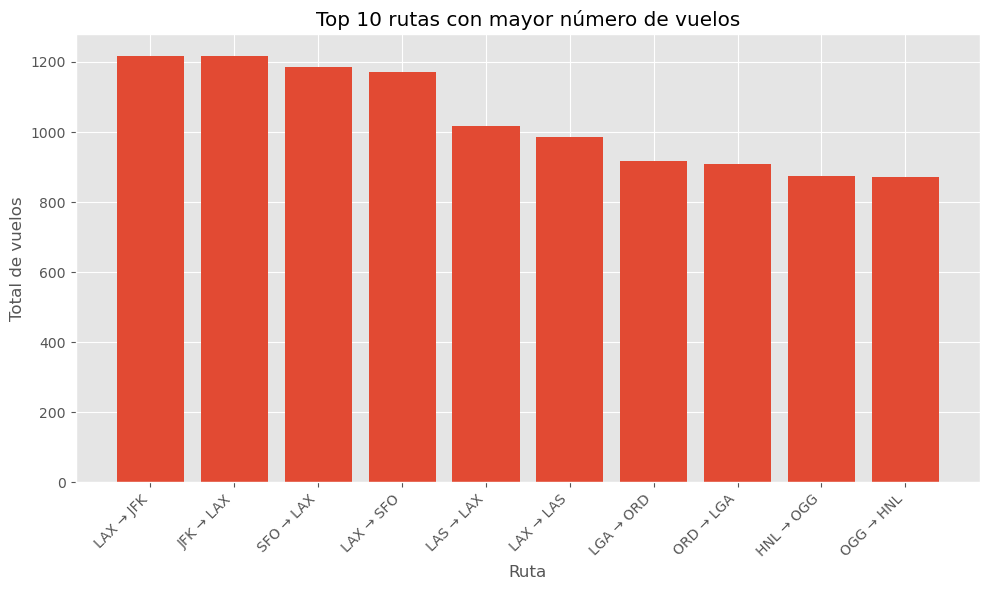

In [14]:
plt.figure(figsize=(10, 6))

labels = df_p1["origin_airport"] + " → " + df_p1["destination_airport"]
plt.bar(labels, df_p1["total_flights"])

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 rutas con mayor número de vuelos")
plt.xlabel("Ruta")
plt.ylabel("Total de vuelos")

plt.tight_layout()
plt.show()

Se observa que las rutas con mayor número de vuelos se concentran entre aeropuertos grandes como LAX, JFK y SFO. En particular, las rutas LAX–JFK y JFK–LAX lideran el ranking, lo que indica una alta demanda en conexiones entre costas. También destacan rutas como SFO–LAX y LAX–SFO, reflejando tráfico intenso dentro de California. En general, las rutas más frecuentes conectan hubs principales.

In [5]:
#P2

query_p2 = """
SELECT 
    airline,
    COUNT(*) AS total_flights,
    SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END) AS total_cancelled,
    ROUND(
        SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END)::numeric
        / COUNT(*) * 100,
        2
    ) AS cancellation_percentage
FROM flights
GROUP BY airline
ORDER BY cancellation_percentage DESC
LIMIT 5;
"""

df_p2 = pd.read_sql(query_p2, replica_engine)
df_p2

,airline,total_flights,total_cancelled,cancellation_percentage
0,MQ,31896,3136,9.83
1,B6,23062,1479,6.41
2,EV,52965,2523,4.76
3,US,35591,1268,3.56
4,UA,40873,1424,3.48


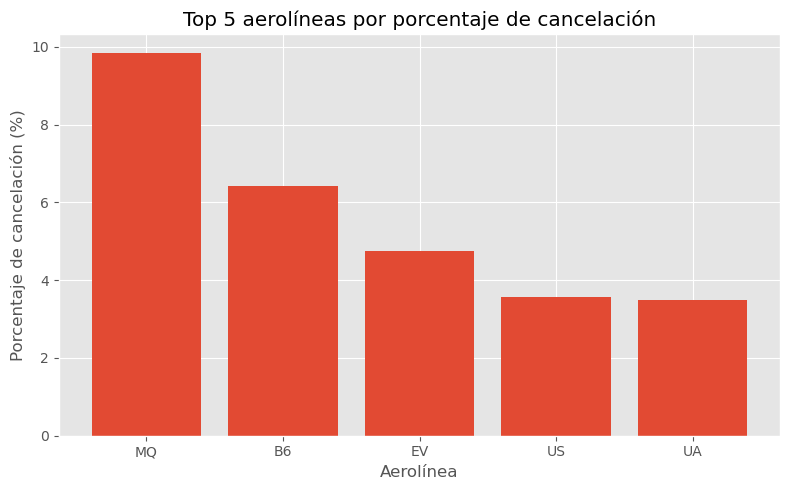

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(df_p2["airline"], df_p2["cancellation_percentage"])

plt.title("Top 5 aerolíneas por porcentaje de cancelación")
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje de cancelación (%)")

plt.tight_layout()
plt.show()

La gráfica muestra que **MQ** es la aerolínea con el mayor porcentaje de cancelación dentro de la muestra analizada, con **9.83%**, superando claramente a las demás. Le siguen **B6** y **EV**, aunque con porcentajes sensiblemente menores. En contraste, **US** y **UA** presentan tasas más bajas dentro del top 5, cercanas a 3.5%. Esto destaca diferencias relevantes en desempeño operativo entre aerolíneas durante el periodo cubierto por la muestra.

In [6]:
# P3

query_p3 = """
SELECT 
    cancellation_reason,
    COUNT(*) AS total_cancelled
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total_cancelled DESC;
"""

df_p3 = pd.read_sql(query_p3, replica_engine)
df_p3

,cancellation_reason,total_cancelled
0,B,10630
1,A,3230
2,C,2962
3,D,2


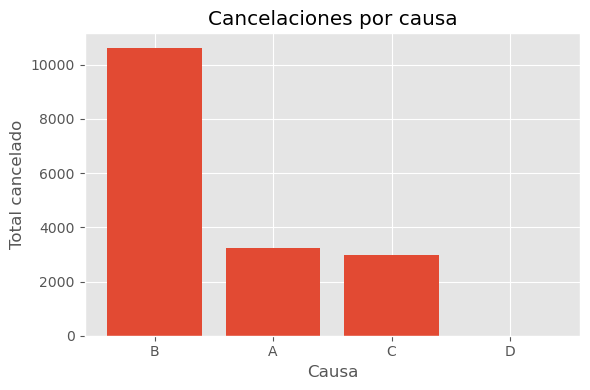

In [16]:
plt.figure(figsize=(6, 4))

plt.bar(df_p3["cancellation_reason"], df_p3["total_cancelled"])

plt.title("Cancelaciones por causa")
plt.xlabel("Causa")
plt.ylabel("Total cancelado")

plt.tight_layout()
plt.show()

La causa de cancelación más frecuente es **B (Weather)**, lo que indica que las condiciones climáticas son el principal factor que afecta la operación de vuelos. Las causas **A (Airline)** y **C (NAS)** tienen un impacto moderado, mientras que **D (Security)** es prácticamente irrelevante. Esto sugiere que factores externos como el clima tienen mayor influencia que problemas operativos internos.

In [7]:
# P4
query_p4 = """
SELECT 
    month,
    ROUND(AVG(departure_delay)::numeric, 2) AS avg_departure_delay
FROM flights
WHERE cancelled = 0
  AND departure_delay > 0
GROUP BY month
ORDER BY month;
"""

df_p4 = pd.read_sql(query_p4, replica_engine)
df_p4

,month,avg_departure_delay
0,1,32.57
1,2,42.31


El retraso promedio de salida aumenta de enero a febrero, pasando de aproximadamente 32.6 a 42.3 minutos. Esto sugiere un deterioro en la puntualidad durante este periodo. Sin embargo, el análisis se basa en un subconjunto del dataset, por lo que no representa el comportamiento completo del año.

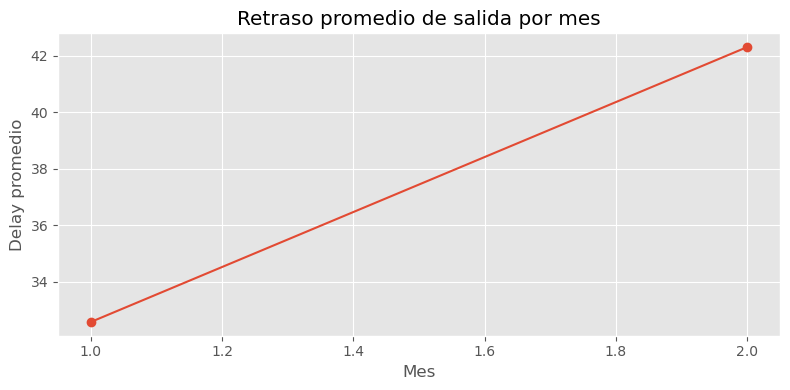

In [17]:
plt.figure(figsize=(8, 4))

plt.plot(df_p4["month"], df_p4["avg_departure_delay"], marker="o")

plt.title("Retraso promedio de salida por mes")
plt.xlabel("Mes")
plt.ylabel("Delay promedio")

plt.tight_layout()
plt.show()

**Nota:** Esta visualización se basa en un subconjunto del dataset (PostgreSQL), que incluye únicamente enero completo y una parte de febrero de 2015. Por ello, la serie de tiempo no representa el comportamiento completo del año.

In [8]:
# P5

query_p5 = """
SELECT 
    origin_airport,
    SUM(COALESCE(weather_delay, 0)) AS total_weather_delay
FROM flights
GROUP BY origin_airport
ORDER BY total_weather_delay DESC
LIMIT 10;
"""

df_p5 = pd.read_sql(query_p5, replica_engine)
df_p5

,origin_airport,total_weather_delay
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


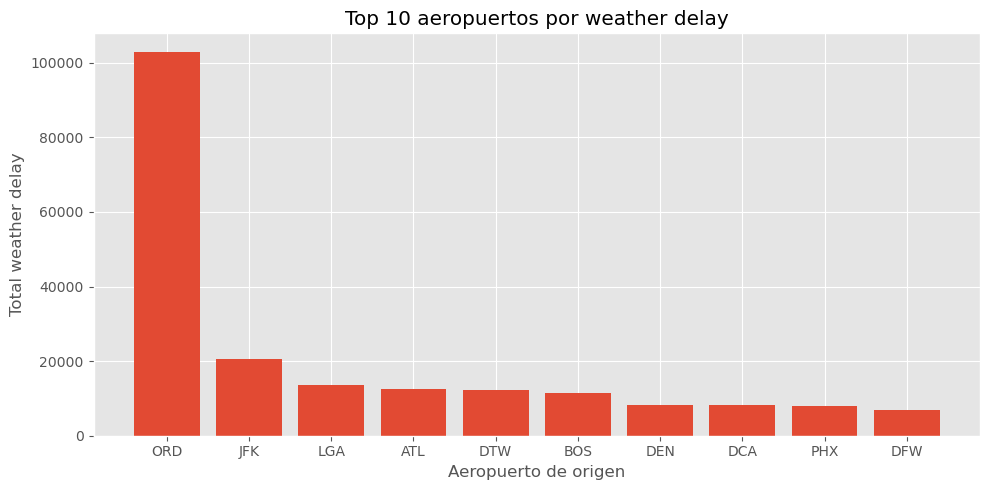

In [18]:
plt.figure(figsize=(10, 5))

plt.bar(df_p5["origin_airport"], df_p5["total_weather_delay"])

plt.title("Top 10 aeropuertos por weather delay")
plt.xlabel("Aeropuerto de origen")
plt.ylabel("Total weather delay")

plt.tight_layout()
plt.show()

El aeropuerto ORD (Chicago O'Hare) concentra, por mucho, la mayor cantidad de retrasos causados por el clima, superando ampliamente al resto de aeropuertos. Esto sugiere que las condiciones meteorológicas en esta ubicación tienen un impacto significativo en las operaciones aéreas. Los demás aeropuertos presentan valores considerablemente menores y más cercanos entre sí, lo que indica una menor incidencia relativa del clima en los retrasos.

In [9]:
# W1

query_w1 = """
WITH ranked_flights AS (
    SELECT
        airline,
        flight_number,
        origin_airport,
        destination_airport,
        arrival_delay,
        RANK() OVER (
            PARTITION BY airline
            ORDER BY arrival_delay DESC NULLS LAST
        ) AS rnk
    FROM flights
)
SELECT
    airline,
    flight_number,
    origin_airport,
    destination_airport,
    arrival_delay
FROM ranked_flights
WHERE rnk = 1
ORDER BY airline;
"""

df_w1 = pd.read_sql(query_w1, replica_engine)
df_w1

,airline,flight_number,origin_airport,destination_airport,arrival_delay
0,AA,1322,BHM,DFW,1971.0
1,AS,455,LAX,SEA,451.0
2,B6,576,MSY,JFK,502.0
3,DL,1435,MIA,MSP,1174.0
4,EV,2567,SHV,DFW,723.0
5,F9,1256,ORD,MIA,686.0
6,HA,51,JFK,HNL,1013.0
7,MQ,2962,CLL,DFW,788.0
8,NK,728,TPA,ORD,570.0
9,OO,2642,CHO,ORD,953.0


In [23]:
df_w1["rank"] = df_w1["arrival_delay"].rank(method="dense", ascending=False)
df_w1.sort_values("rank")

,airline,flight_number,origin_airport,destination_airport,arrival_delay,rank
0,AA,1322,BHM,DFW,1971.0,1.0
3,DL,1435,MIA,MSP,1174.0,2.0
6,HA,51,JFK,HNL,1013.0,3.0
9,OO,2642,CHO,ORD,953.0,4.0
10,UA,1443,ICT,DEN,863.0,5.0
7,MQ,2962,CLL,DFW,788.0,6.0
4,EV,2567,SHV,DFW,723.0,7.0
5,F9,1256,ORD,MIA,686.0,8.0
11,US,1782,SEA,CLT,621.0,9.0
13,WN,259,IAD,DEN,593.0,10.0


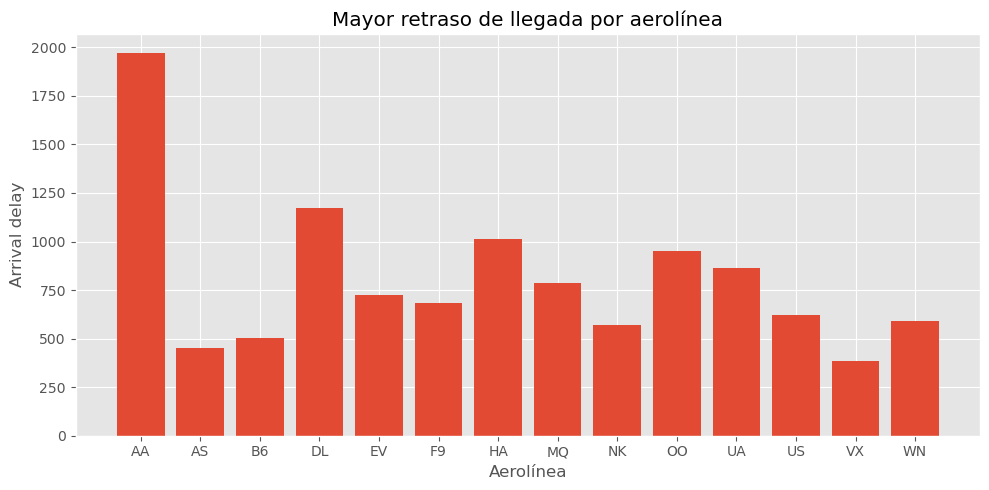

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(df_w1["airline"], df_w1["arrival_delay"])

plt.title("Mayor retraso de llegada por aerolínea")
plt.xlabel("Aerolínea")
plt.ylabel("Arrival delay")

plt.tight_layout()
plt.show()

El vuelo con mayor retraso de llegada pertenece a la aerolínea AA, con un retraso cercano a los 2000 minutos, muy por encima del resto. A partir del segundo lugar (DL) y siguientes, los retrasos disminuyen considerablemente, aunque aún se mantienen en valores altos.

En general, no se observa que una sola aerolínea concentre todos los mayores retrasos, ya que varias aerolíneas aparecen en el ranking. Esto sugiere que los retrasos extremos son eventos aislados más que un problema sistemático de una sola compañía.

In [10]:
# W3

query_w3 = """
WITH ordered_flights AS (
    SELECT
        flight_number,
        airline,
        destination_airport,
        scheduled_departure,
        ROW_NUMBER() OVER (
            PARTITION BY year, month, day, origin_airport
            ORDER BY scheduled_departure ASC
        ) AS rn
    FROM flights
    WHERE year = 2015
      AND month = 1
      AND day = 1
      AND origin_airport = 'LAX'
)
SELECT
    flight_number,
    airline,
    destination_airport,
    scheduled_departure
FROM ordered_flights
WHERE rn <= 5
ORDER BY rn;
"""

df_w3 = pd.read_sql(query_w3, replica_engine)
df_w3

,flight_number,airline,destination_airport,scheduled_departure
0,2336,AA,PBI,10
1,258,AA,MIA,20
2,2013,US,CLT,30
3,1434,DL,MSP,35
4,115,AA,MIA,105


In [24]:
df_w3["rank"] = df_w3["scheduled_departure"].rank(method="dense", ascending=True)
df_w3.sort_values("rank")

,flight_number,airline,destination_airport,scheduled_departure,rank
0,2336,AA,PBI,10,1.0
1,258,AA,MIA,20,2.0
2,2013,US,CLT,30,3.0
3,1434,DL,MSP,35,4.0
4,115,AA,MIA,105,5.0


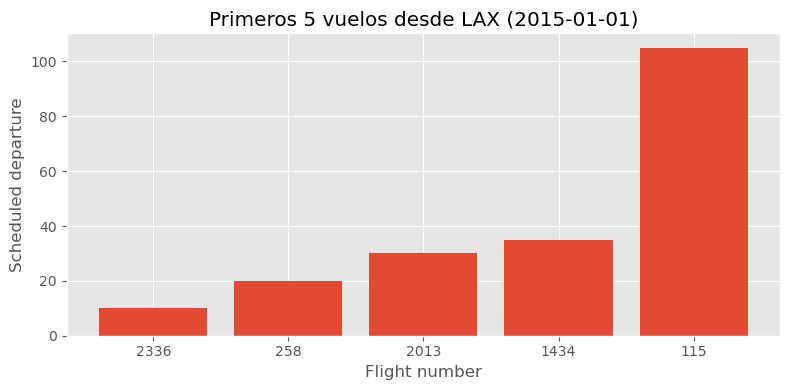

In [21]:
plt.figure(figsize=(8, 4))

plt.bar(df_w3["flight_number"].astype(str), df_w3["scheduled_departure"])

plt.title("Primeros 5 vuelos desde LAX (2015-01-01)")
plt.xlabel("Flight number")
plt.ylabel("Scheduled departure")

plt.tight_layout()
plt.show()

Los primeros vuelos programados desde LAX el 1 de enero de 2015 muestran un incremento progresivo en la hora de salida programada, comenzando desde valores muy bajos (10, 20, 30 minutos después de medianoche) hasta horarios posteriores.

Esto refleja la secuencia natural de salidas a lo largo de la madrugada, donde los vuelos se programan en intervalos crecientes. No se observan anomalías en la programación, sino un patrón consistente con la operación normal de un aeropuerto.

## W2 en Athena

Esta pregunta se responde sobre `flights_silver.flights_monthly` en Athena, ya que PostgreSQL contiene únicamente una muestra parcial del dataset.

In [13]:
# W2

query_w2 = """
WITH monthly_totals AS (
    SELECT
        month,
        SUM(total_flights) AS total_flights
    FROM flights_silver.flights_monthly
    GROUP BY month
),
monthly_with_lag AS (
    SELECT
        month,
        total_flights,
        LAG(total_flights) OVER (ORDER BY month) AS prev_month_flights
    FROM monthly_totals
)
SELECT
    month,
    total_flights,
    prev_month_flights,
    total_flights - prev_month_flights AS abs_change,
    ROUND(
        100.0 * (total_flights - prev_month_flights) / NULLIF(prev_month_flights, 0),
        2
    ) AS pct_change
FROM monthly_with_lag
ORDER BY month
"""

df_w2 = wr.athena.read_sql_query(
    sql=query_w2,
    database="flights_silver",
    ctas_approach=False
)

df_w2

2026-04-09 22:07:47,362	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409960448 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.71gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-09 22:07:48,634	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,prev_month_flights,abs_change,pct_change
0,1,469968,<NA>,<NA>,NaN
1,2,429191,469968,-40777,-8.68
2,3,504312,429191,75121,17.50
3,4,485151,504312,-19161,-3.80
4,5,496993,485151,11842,2.44
5,6,503897,496993,6904,1.39
6,7,520718,503897,16821,3.34
7,8,510536,520718,-10182,-1.96
8,9,464946,510536,-45590,-8.93
9,10,486165,464946,21219,4.56


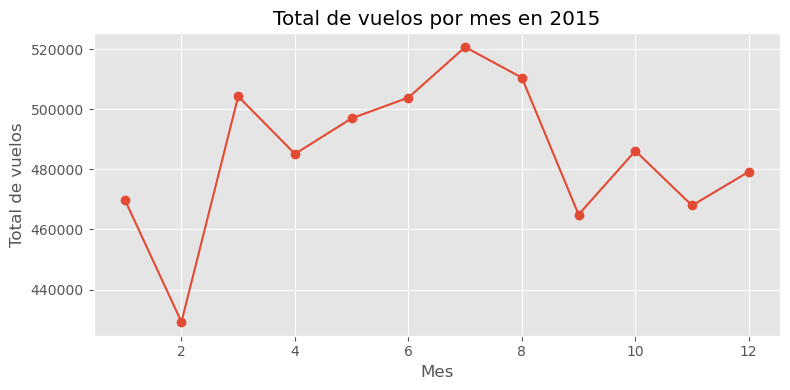

In [20]:
plt.figure(figsize=(8, 4))

plt.plot(df_w2["month"], df_w2["total_flights"], marker="o")

plt.title("Total de vuelos por mes en 2015")
plt.xlabel("Mes")
plt.ylabel("Total de vuelos")

plt.tight_layout()
plt.show()

El número total de vuelos en 2015 muestra variaciones a lo largo del año. Se observa una caída en febrero, seguida de un aumento sostenido hasta alcanzar su punto máximo en julio. A partir de ahí, el número de vuelos disminuye nuevamente hacia septiembre, con algunas fluctuaciones en los meses finales del año.

Este patrón sugiere un comportamiento estacional, donde los meses de verano presentan mayor actividad aérea, mientras que meses como febrero y septiembre muestran menor volumen de vuelos.

# Análisis Estadístico

## 8.1 Regresión lineal — ¿Qué factores explican el retraso de llegada?

En esta sección se ajusta un modelo OLS para cuantificar la contribución de distintas causas de retraso sobre `arrival_delay`. El objetivo no es construir un modelo predictivo, sino analizar el peso relativo de cada variable explicativa.

In [3]:
import numpy as np
import pandas as pd
import awswrangler as wr
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_squared_error

plt.style.use("ggplot")

In [5]:
df_reg = wr.athena.read_sql_query(
    sql="""
    SELECT
        arrival_delay,
        departure_delay,
        distance,
        air_system_delay,
        airline_delay,
        weather_delay,
        late_aircraft_delay,
        security_delay
    FROM flights_gold.vuelos_analitica
    WHERE cancelled = 0
      AND arrival_delay IS NOT NULL
      AND departure_delay IS NOT NULL
      AND distance IS NOT NULL
      AND rand() < 0.05
    """,
    database="flights_gold",
    ctas_approach=False,
    use_threads=False
)

df_reg.head()

,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
0,-21.0,-6.0,601,NaN,NaN,NaN,NaN,NaN
1,-4.0,1.0,862,NaN,NaN,NaN,NaN,NaN
2,-9.0,-5.0,828,NaN,NaN,NaN,NaN,NaN
3,-6.0,-2.0,957,NaN,NaN,NaN,NaN,NaN
4,-13.0,4.0,590,NaN,NaN,NaN,NaN,NaN


In [6]:
delay_cols = [
    "air_system_delay",
    "airline_delay",
    "weather_delay",
    "late_aircraft_delay",
    "security_delay",
]

df_reg = df_reg.copy()
df_reg[delay_cols] = df_reg[delay_cols].fillna(0)

df_reg.head()

,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
0,-21.0,-6.0,601,0.0,0.0,0.0,0.0,0.0
1,-4.0,1.0,862,0.0,0.0,0.0,0.0,0.0
2,-9.0,-5.0,828,0.0,0.0,0.0,0.0,0.0
3,-6.0,-2.0,957,0.0,0.0,0.0,0.0,0.0
4,-13.0,4.0,590,0.0,0.0,0.0,0.0,0.0


### Preparar variables y ajustar OLS

In [8]:
features = [
    "departure_delay",
    "distance",
    "air_system_delay",
    "airline_delay",
    "weather_delay",
    "late_aircraft_delay",
    "security_delay",
]

df_reg = df_reg.dropna(subset=["arrival_delay", "departure_delay", "distance"]).copy()

X = df_reg[features].astype(float)
y = df_reg["arrival_delay"].astype(float)

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          arrival_delay   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 6.640e+05
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:26:12   Log-Likelihood:            -1.0452e+06
No. Observations:              284917   AIC:                         2.090e+06
Df Residuals:                  284909   BIC:                         2.090e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -4.9324    

In [9]:
y_hat = model.predict(X_const)
residuals = y - y_hat

r2 = model.rsquared
rmse = np.sqrt(mean_squared_error(y, y_hat))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.9422
RMSE: 9.4828


El modelo OLS presenta un R² de 0.9422, lo que indica que aproximadamente el 94.22% de la variabilidad en el retraso de llegada (`arrival_delay`) es explicada por las variables incluidas. Esto sugiere un muy buen ajuste del modelo. El RMSE es de 9.48 minutos, lo que indica que, en promedio, el error de predicción del modelo es menor a 10 minutos.

### Intervalos de confianza y coeficientes

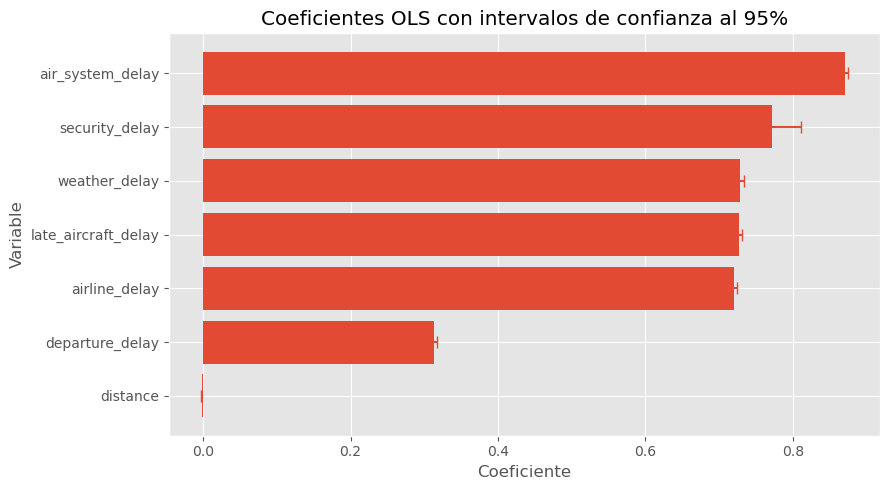

,coef,ci_low,ci_high
distance,-0.002301,-0.002359,-0.002244
departure_delay,0.313761,0.310160,0.317362
airline_delay,0.719721,0.715672,0.723769
late_aircraft_delay,0.726943,0.722791,0.731095
weather_delay,0.728436,0.723110,0.733762
security_delay,0.772197,0.733236,0.811159
air_system_delay,0.870713,0.867115,0.874310


In [11]:
coef_table = model.params.to_frame("coef")
conf_int = model.conf_int()
coef_table["ci_low"] = conf_int[0]
coef_table["ci_high"] = conf_int[1]

coef_table = coef_table.drop(index="const").sort_values("coef")

plt.figure(figsize=(9, 5))
plt.barh(coef_table.index, coef_table["coef"])
plt.errorbar(
    x=coef_table["coef"],
    y=np.arange(len(coef_table)),
    xerr=[
        coef_table["coef"] - coef_table["ci_low"],
        coef_table["ci_high"] - coef_table["coef"],
    ],
    fmt="none",
    capsize=4,
)
plt.title("Coeficientes OLS con intervalos de confianza al 95%")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

coef_table

En los coeficientes, se observa que las variables relacionadas con causas específicas de retraso (`air_system_delay`, `airline_delay`, `weather_delay`, `late_aircraft_delay` y `security_delay`) tienen los mayores impactos positivos sobre el retraso de llegada, siendo `air_system_delay` la más influyente. Por otro lado, `distance` presenta un coeficiente negativo muy pequeño, indicando que su efecto es prácticamente despreciable en comparación con las demás variables.


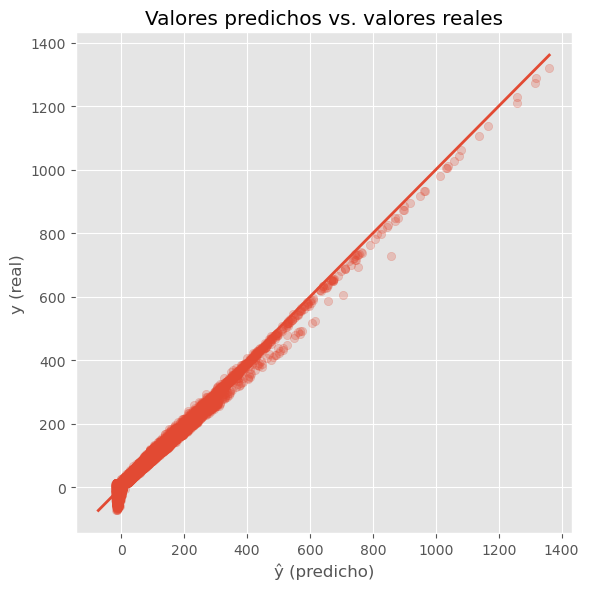

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_hat, y, alpha=0.25)

lims = [
    min(y_hat.min(), y.min()),
    max(y_hat.max(), y.max())
]
plt.plot(lims, lims, linewidth=2)

plt.title("Valores predichos vs. valores reales")
plt.xlabel("ŷ (predicho)")
plt.ylabel("y (real)")
plt.tight_layout()
plt.show()

El gráfico de valores predichos vs. reales muestra que los puntos se alinean muy cercanamente a la línea diagonal, lo que confirma el buen desempeño del modelo. Sin embargo, esta alta alineación también es esperada debido a la inclusión de variables que componen directamente el retraso total, lo que introduce multicolinealidad.

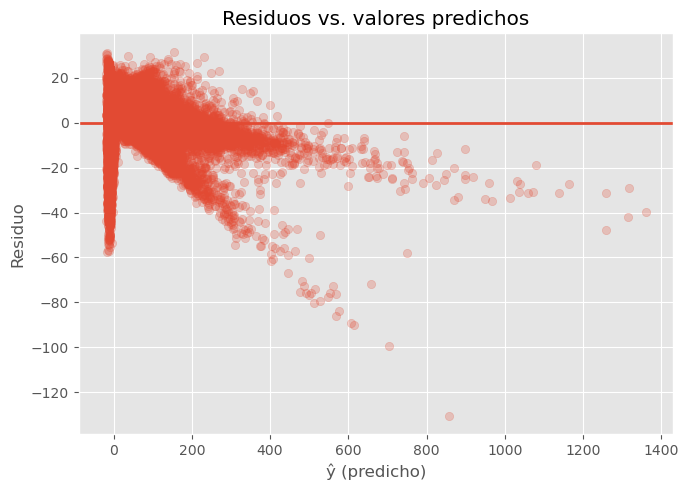

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(y_hat, residuals, alpha=0.25)
plt.axhline(0, linewidth=2)

plt.title("Residuos vs. valores predichos")
plt.xlabel("ŷ (predicho)")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()

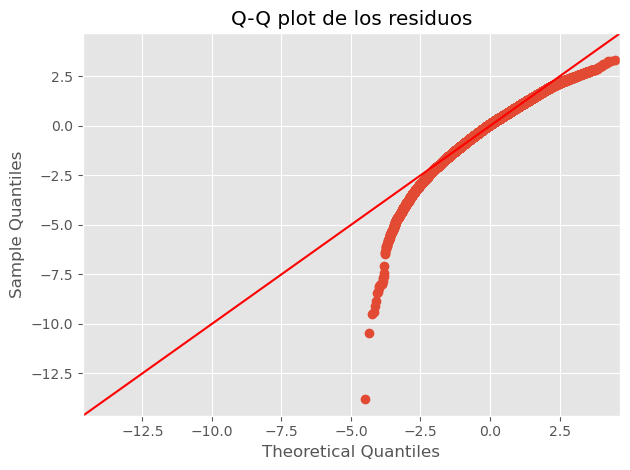

In [14]:
qqplot(residuals, line="45", fit=True)
plt.title("Q-Q plot de los residuos")
plt.tight_layout()
plt.show()

El análisis de residuos sugiere que no están perfectamente distribuidos de manera aleatoria, y el Q-Q plot muestra desviaciones en las colas respecto a la normalidad. Esto indica que los residuos no siguen una distribución normal, lo cual puede afectar la validez de los intervalos de confianza. Además, el alto condition number reportado en el modelo confirma la presencia de multicolinealidad, lo cual era esperado dado que las variables de retraso están altamente correlacionadas entre sí.

## 8.2 Pronóstico de series de tiempo — vuelos mensuales

Se construye una serie de tiempo con el número total de vuelos mensuales en 2015 y se aplican tres modelos automáticos de StatsForecast: AutoETS, AutoARIMA y AutoTheta. Se evalúa el desempeño en un conjunto de test (últimos 3 meses) y se generan pronósticos para los siguientes 6 meses.

In [16]:
!pip install statsforecast

In [17]:
import pandas as pd
import numpy as np
import awswrangler as wr
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta

plt.style.use("ggplot")

### Leer datos desde Athena

In [20]:
df_ts = wr.athena.read_sql_query(
    """
    SELECT
        month,
        SUM(total_flights) AS total_flights
    FROM flights_silver.flights_monthly
    GROUP BY month
    ORDER BY month
    """,
    database="flights_silver"
)

df_ts

,month,total_flights
0,1,469968
1,2,429191
2,3,504312
3,4,485151
4,5,496993
5,6,503897
6,7,520718
7,8,510536
8,9,464946
9,10,486165


In [21]:
df_ts["ds"] = pd.to_datetime("2015-" + df_ts["month"].astype(str).str.zfill(2) + "-01")
df_ts["unique_id"] = "flights"
df_ts["y"] = df_ts["total_flights"].astype(float)

df_ts = df_ts[["unique_id", "ds", "y"]].sort_values("ds")

df_ts

,unique_id,ds,y
0,flights,2015-01-01,469968.0
1,flights,2015-02-01,429191.0
2,flights,2015-03-01,504312.0
3,flights,2015-04-01,485151.0
4,flights,2015-05-01,496993.0
5,flights,2015-06-01,503897.0
6,flights,2015-07-01,520718.0
7,flights,2015-08-01,510536.0
8,flights,2015-09-01,464946.0
9,flights,2015-10-01,486165.0


In [22]:
train = df_ts.iloc[:9].copy()   # enero-septiembre
test = df_ts.iloc[9:].copy()    # octubre-diciembre

train

,unique_id,ds,y
0,flights,2015-01-01,469968.0
1,flights,2015-02-01,429191.0
2,flights,2015-03-01,504312.0
3,flights,2015-04-01,485151.0
4,flights,2015-05-01,496993.0
5,flights,2015-06-01,503897.0
6,flights,2015-07-01,520718.0
7,flights,2015-08-01,510536.0
8,flights,2015-09-01,464946.0


In [23]:
test

,unique_id,ds,y
9,flights,2015-10-01,486165.0
10,flights,2015-11-01,467972.0
11,flights,2015-12-01,479230.0


### Definimos los modelos

In [24]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta
from sklearn.metrics import mean_absolute_error

models = [
    AutoETS(season_length=12),
    AutoARIMA(season_length=12),
    AutoTheta(season_length=12),
]

In [26]:
sf = StatsForecast(
    models=models,
    freq="MS",
    n_jobs=1
)

sf.fit(train)

StatsForecast(models=[AutoETS,AutoARIMA,AutoTheta])

### Forecast a 9  pasos

In [27]:
forecast = sf.predict(h=9, level=[90]).reset_index()

forecast

,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,0,flights,2015-10-01,487319.908434,428025.166318,546614.650550,487301.333333,440427.078218,534175.588448,496523.548340,465489.479687,535667.421875
1,1,flights,2015-11-01,487319.908434,428025.166022,546614.650847,487301.333333,440427.078218,534175.588448,496524.261068,460775.689063,525887.603125
2,2,flights,2015-12-01,487319.908434,428025.165725,546614.651143,487301.333333,440427.078218,534175.588448,496524.973796,453725.757812,529276.887500
3,3,flights,2016-01-01,487319.908434,428025.165429,546614.651440,487301.333333,440427.078218,534175.588448,496525.686524,460986.335938,525810.528125
4,4,flights,2016-02-01,487319.908434,428025.165132,546614.651736,487301.333333,440427.078218,534175.588448,496526.399252,466634.279687,533010.103125
5,5,flights,2016-03-01,487319.908434,428025.164836,546614.652033,487301.333333,440427.078218,534175.588448,496527.111980,463863.089062,530507.737500
6,6,flights,2016-04-01,487319.908434,428025.164539,546614.652329,487301.333333,440427.078218,534175.588448,496527.824708,460121.359375,532280.328125
7,7,flights,2016-05-01,487319.908434,428025.164243,546614.652625,487301.333333,440427.078218,534175.588448,496528.537435,461351.543750,532693.590625
8,8,flights,2016-06-01,487319.908434,428025.163947,546614.652922,487301.333333,440427.078218,534175.588448,496529.250163,459872.057812,532316.259375


In [28]:
forecast_test = forecast.iloc[:3].copy()    # oct-dic 2015
forecast_future = forecast.iloc[3:].copy()  # ene-jun 2016

forecast_test

,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,0,flights,2015-10-01,487319.908434,428025.166318,546614.650550,487301.333333,440427.078218,534175.588448,496523.548340,465489.479687,535667.421875
1,1,flights,2015-11-01,487319.908434,428025.166022,546614.650847,487301.333333,440427.078218,534175.588448,496524.261068,460775.689063,525887.603125
2,2,flights,2015-12-01,487319.908434,428025.165725,546614.651143,487301.333333,440427.078218,534175.588448,496524.973796,453725.757812,529276.887500


In [29]:
forecast_future

,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
3,3,flights,2016-01-01,487319.908434,428025.165429,546614.651440,487301.333333,440427.078218,534175.588448,496525.686524,460986.335938,525810.528125
4,4,flights,2016-02-01,487319.908434,428025.165132,546614.651736,487301.333333,440427.078218,534175.588448,496526.399252,466634.279687,533010.103125
5,5,flights,2016-03-01,487319.908434,428025.164836,546614.652033,487301.333333,440427.078218,534175.588448,496527.111980,463863.089062,530507.737500
6,6,flights,2016-04-01,487319.908434,428025.164539,546614.652329,487301.333333,440427.078218,534175.588448,496527.824708,460121.359375,532280.328125
7,7,flights,2016-05-01,487319.908434,428025.164243,546614.652625,487301.333333,440427.078218,534175.588448,496528.537435,461351.543750,532693.590625
8,8,flights,2016-06-01,487319.908434,428025.163947,546614.652922,487301.333333,440427.078218,534175.588448,496529.250163,459872.057812,532316.259375


### MAE

In [30]:
mae_results = {}

for model in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    mae_results[model] = mean_absolute_error(test["y"], forecast_test[model])

mae_df = pd.DataFrame(
    list(mae_results.items()),
    columns=["Modelo", "MAE"]
).sort_values("MAE")

mae_df

,Modelo,MAE
1,AutoARIMA,9512.333333
0,AutoETS,9530.908434
2,AutoTheta,18735.261068


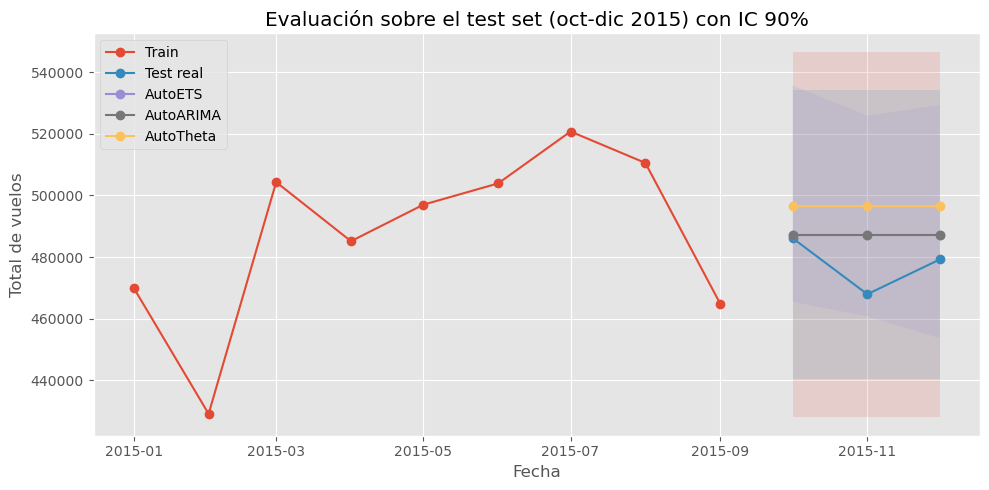

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(train["ds"], train["y"], marker="o", label="Train")
plt.plot(test["ds"], test["y"], marker="o", label="Test real")

for model in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    plt.plot(forecast_test["ds"], forecast_test[model], marker="o", label=model)
    
    plt.fill_between(
        forecast_test["ds"],
        forecast_test[f"{model}-lo-90"],
        forecast_test[f"{model}-hi-90"],
        alpha=0.15
    )

plt.title("Evaluación sobre el test set (oct-dic 2015) con IC 90%")
plt.xlabel("Fecha")
plt.ylabel("Total de vuelos")
plt.legend()
plt.tight_layout()
plt.show()

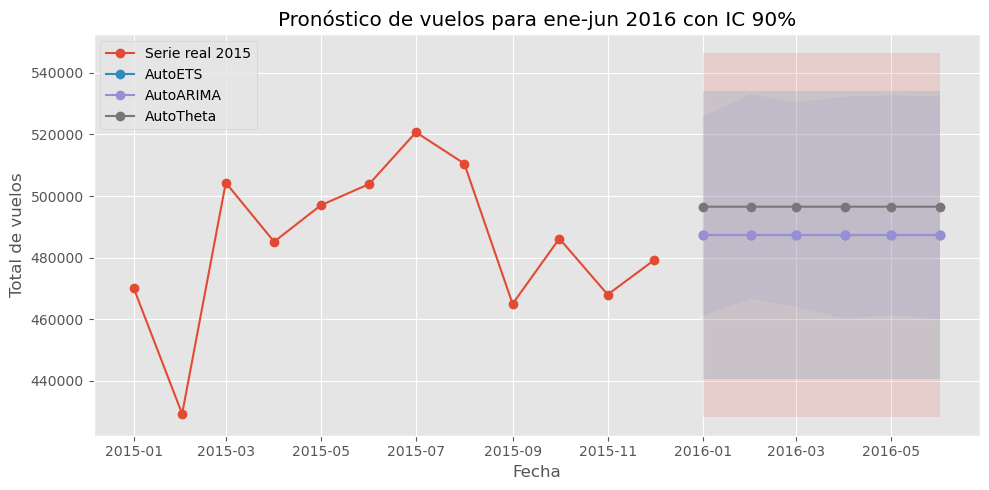

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(df_ts["ds"], df_ts["y"], marker="o", label="Serie real 2015")

for model in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    plt.plot(forecast_future["ds"], forecast_future[model], marker="o", label=model)
    
    plt.fill_between(
        forecast_future["ds"],
        forecast_future[f"{model}-lo-90"],
        forecast_future[f"{model}-hi-90"],
        alpha=0.15
    )

plt.title("Pronóstico de vuelos para ene-jun 2016 con IC 90%")
plt.xlabel("Fecha")
plt.ylabel("Total de vuelos")
plt.legend()
plt.tight_layout()
plt.show()

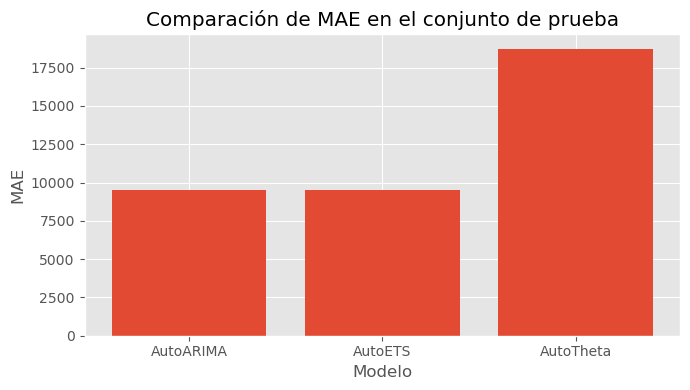

,Modelo,MAE
1,AutoARIMA,9512.333333
0,AutoETS,9530.908434
2,AutoTheta,18735.261068


In [33]:
plt.figure(figsize=(7, 4))
plt.bar(mae_df["Modelo"], mae_df["MAE"])
plt.title("Comparación de MAE en el conjunto de prueba")
plt.xlabel("Modelo")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

mae_df

In [39]:
best_model = mae_df.iloc[0]["Modelo"]
best_mae = mae_df.iloc[0]["MAE"]

print(f"Mejor modelo según MAE: {best_model}")
print(f"MAE del mejor modelo: {best_mae:.2f}")

Mejor modelo según MAE: AutoARIMA
MAE del mejor modelo: 9512.33


### Interpretación del pronóstico

Para construir la serie de tiempo mensual fue necesario agregar los datos por mes, ya que la tabla original estaba desagregada por aerolínea. A partir de esta serie se entrenaron tres modelos automáticos: AutoETS, AutoARIMA y AutoTheta.

El modelo AutoARIMA obtuvo el menor MAE en el conjunto de prueba (9512.33), por lo que fue el de mejor desempeño entre los tres, seguido muy de cerca por AutoETS. En cambio, AutoTheta presentó un error claramente mayor, lo que indica un ajuste menos preciso para esta serie.

Las bandas de confianza al 90% muestran la incertidumbre asociada a las predicciones. Dado que solo se cuenta con un año de datos y únicamente 9 observaciones en entrenamiento, estas bandas deben interpretarse con cautela: los pronósticos son útiles como referencia de nivel esperado, pero no como estimaciones de alta certidumbre. Además, con tan pocos datos, es esperable que los modelos seleccionen especificaciones no estacionales.